In [1]:
import utils
import numpy as np
import pandas as pd
import os
import importlib
import re
from matplotlib.pyplot import cm

importlib.reload(utils)

import matplotlib.pyplot as plt
import seaborn as sns # Loads in the theme

#pd.set_option('display.max_rows', None)
#pd.set_option('display.max_columns', 20)
#pd.set_option('display.width', 150)

## Todo
When fixing this, copy Koutsoumpari's 2025 work

In [2]:
# Preparation
dataset = 'pilot' # TUS, joystick, speakup, africa

# Loads the datapath, subject_id's and session numbers based on whether we're analysing the study or pilot data
if dataset == 'TUS' or dataset == 'joystick':
    raw_output_path = '/Volumes/project/3025011.02/raw'
    unique_subject_ids = [52, 53, 54, 55, 57]
    unique_sessions = [2, 3, 4]
elif dataset == 'pilot':
    raw_output_path = '/Volumes/project/3025011.02/long_experiment_data/phd_1_task/experiment_output'
    unique_subject_ids = [5, 10, 14, 15, 16, 20, 22, 23, 25, 28, 29, 37, 38]
    unique_sessions = [2, 3, 4]
elif dataset=='speakup':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/190526/raw'
    unique_subject_ids = [2, 3, 5, 6, 7, 8, 9, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47, 48, 49, 50, 51, 53]
    unique_sessions = [3]
elif dataset=='africa':
    raw_output_path = '/Volumes/project/3025011.01/4kenneth/RL_task-speakup_version_martin_southafrica/experiment_output'
    unique_subject_ids = [2, 3, 4, 5, 6, 8, 9, 10, 12, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28]
    unique_sessions = [1]

# Make output folder
output_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/{dataset}/behavioural/WSLS'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Load and combine the datasets
combined_results_dataframe = utils.import_functions.main(raw_output_path, unique_subject_ids, unique_sessions, dataset)

These participants will be excluded: {'sub-011_session-02', 'sub-011_session-01', 'sub-016_session-04', 'sub-011_session-03', 'sub-011_session-04'}



In [3]:
#combined_results_dataframe = combined_results_dataframe[combined_results_dataframe['trials_since_reversal_separate_learning']<=10]

# Win-stay plots
# Win-stay behaviour

In [4]:
# Filter out the trials where there was no win-stay or win-shift
combos = combined_results_dataframe[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
combined_results_dataframe_WS = combined_results_dataframe[combined_results_dataframe['win-stay'] != 0]
combos = combined_results_dataframe_WS[['subject_id','session']].drop_duplicates().sort_values(['subject_id','session'])
print(combos)
# Replace -1 by 0's
combined_results_dataframe_WS['win-stay'] = combined_results_dataframe_WS['win-stay'].replace(-1, 0)
combined_results_dataframe_WS['win-stay'] = combined_results_dataframe_WS['win-stay'].replace(1, 100)

       subject_id  session
0               5        2
443             5        3
886             5        4
1329           10        2
1772           10        3
2215           10        4
2658           14        2
3101           14        3
3544           14        4
3987           15        2
4430           15        3
4873           15        4
5316           16        2
5759           16        3
6202           20        2
6645           20        3
7088           20        4
7531           22        2
7974           22        3
8417           22        4
8860           23        2
9303           23        3
9746           23        4
10189          25        2
10632          25        3
11075          25        4
11518          28        2
11961          28        3
12404          28        4
12847          29        2
13290          29        3
13733          29        4
14176          37        2
14619          37        3
15062          37        4
15505          38        2
1

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2406/2442031106.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['win-stay'] = combined_results_dataframe_WS['win-stay'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2406/2442031106.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_WS['win-stay'] = combined_results_dataframe_WS['win-stay'].replace(1, 100)


# Sanity checks

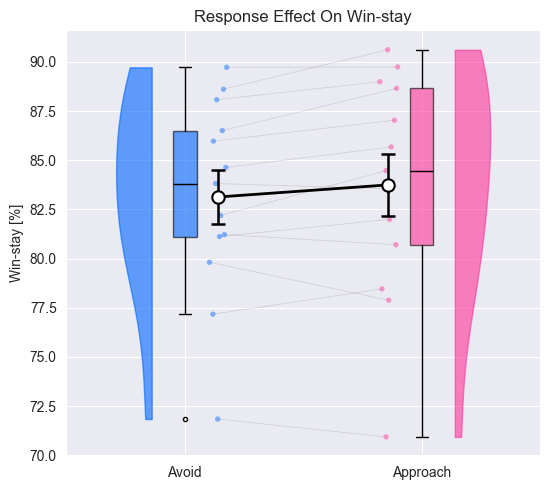

In [5]:
# Check for a response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id'],
        columns='response',
        values='win-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['avoid','approach'],
    labels=['Avoid', 'Approach'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Win-stay [%]',
    plot_name='response effect on win-stay'
);

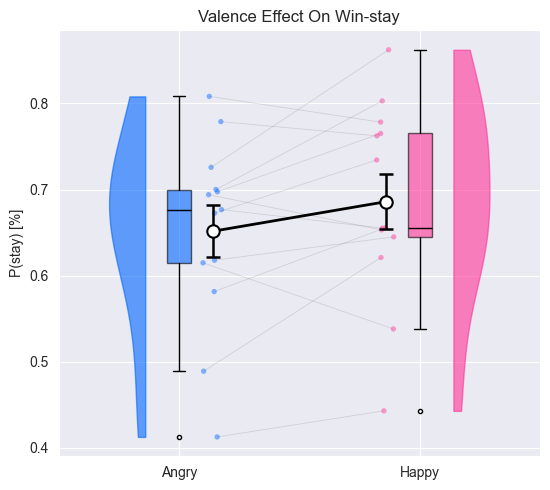

In [6]:
# Participants might show a propensity for win-cues, letting the positive cues entangle with the positive feedback. Koutsompari et al. (2025) describe this as a perseveration bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id'],
        columns='valence',
        values='stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry', 'happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='p(stay) [%]',
    plot_name='valence effect on win-stay'
);

# Actual analyses

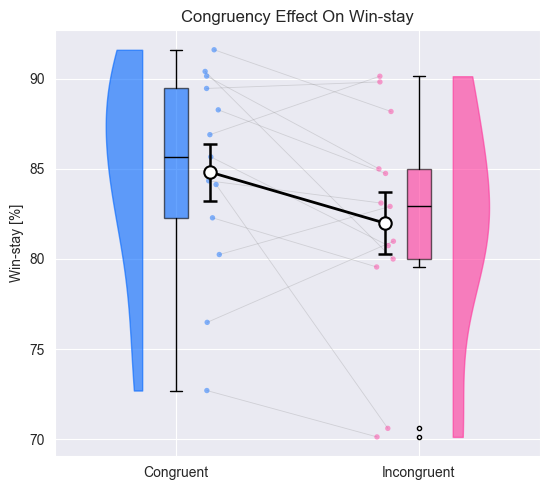

In [7]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_WS
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='win-stay',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    labels=['Congruent', 'Incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Win-stay [%]',
    plot_name='congruency effect on win-stay'
);

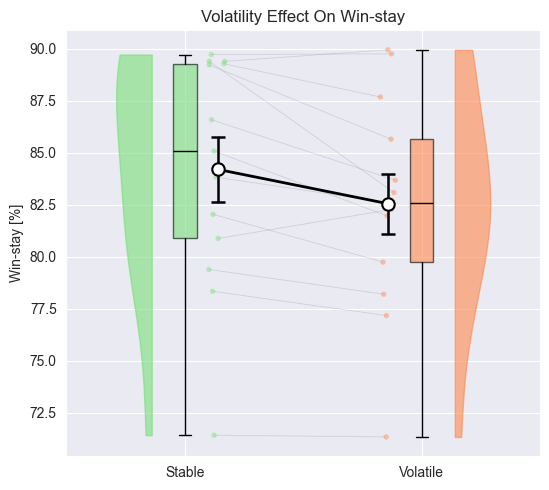

In [8]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_WS
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        labels=['Stable', 'Volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='Win-stay [%]',
        plot_name='volatility effect on win-stay',
        colours=['#77DF77', '#FF884D']
    );

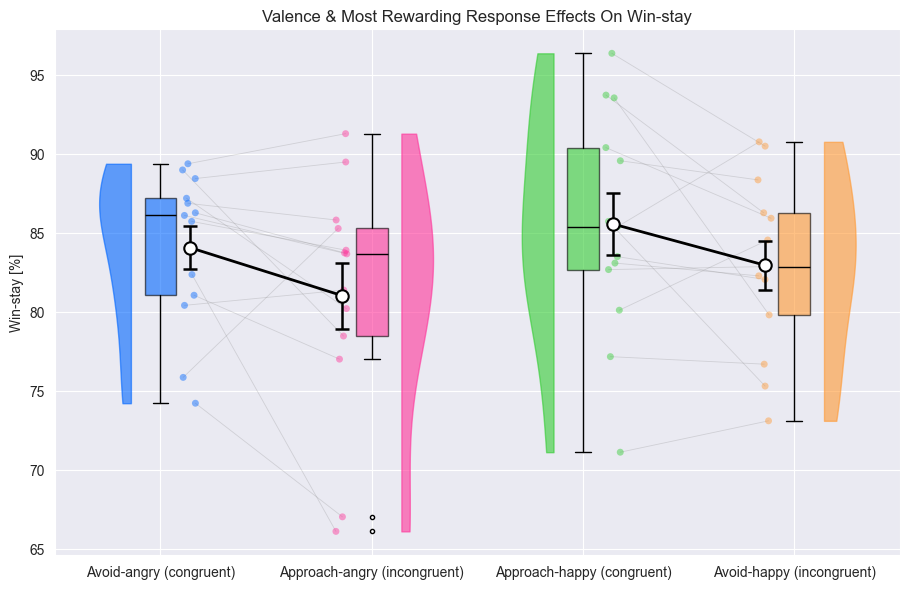

In [9]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_WS
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='Win-stay [%]',
        plot_name='valence & most rewarding response effects on win-stay'
    );

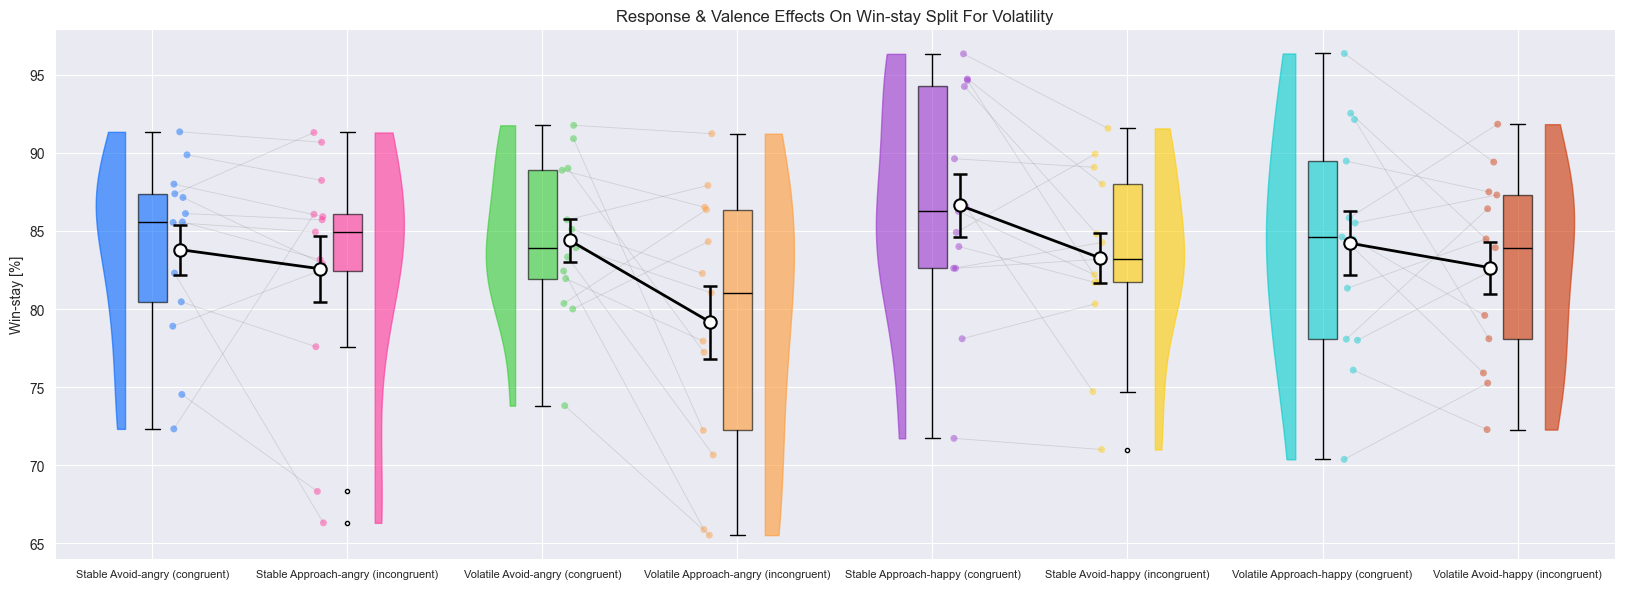

In [10]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_WS
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='win-stay',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='win-stay [%]',
        plot_name='response & valence effects on win-stay split for volatility'
    );

# Lose-shift plots
## Subjective lose-stay behaviour

In [11]:
# Filter out the trials where there was no win-stay or win-shift
combined_results_dataframe_LS = combined_results_dataframe[combined_results_dataframe['lose-shift'] != 0]
# Replace -1 by 0's
combined_results_dataframe_LS['lose-shift'] = combined_results_dataframe_LS['lose-shift'].replace(-1, 0)
combined_results_dataframe_LS['lose-shift'] = combined_results_dataframe_LS['lose-shift'].replace(1, 100)

/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2406/1313291965.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['lose-shift'] = combined_results_dataframe_LS['lose-shift'].replace(-1, 0)
/var/folders/bh/ld02p1_550d75y0x32dmpb540000gp/T/ipykernel_2406/1313291965.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  combined_results_dataframe_LS['lose-shift'] = combined_results_dataframe_LS['lose-shift'].replace(1, 100)


# Sanity checks

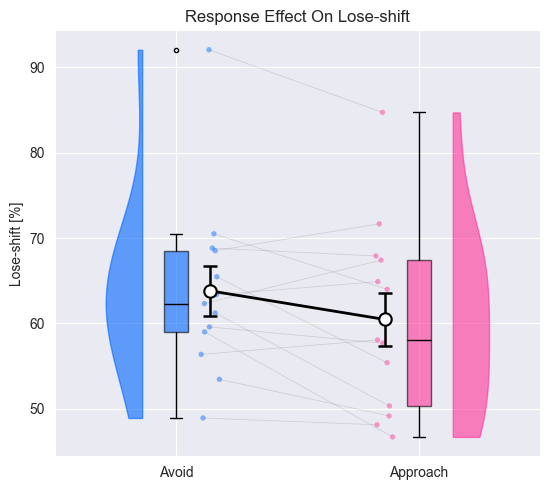

In [12]:
# Check for response bias

# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id'],
        columns='response',
        values='lose-shift',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['avoid','approach'],
    labels=['Avoid', 'Approach'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Lose-shift [%]',
    plot_name='response effect on lose-shift'
);

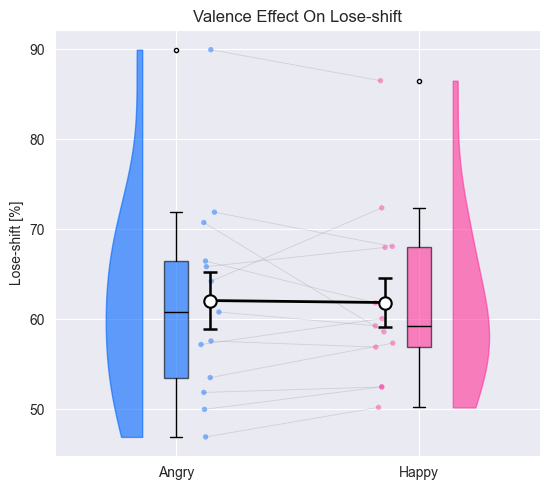

In [13]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id'],
        columns='valence',
        values='lose-shift',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['angry','happy'],
    labels=['Angry', 'Happy'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Lose-shift [%]',
    plot_name='valence effect on lose-shift'
);

# Actual analyses

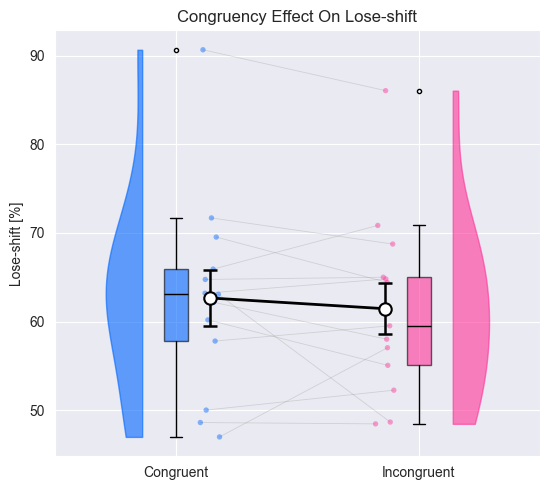

In [14]:
# Single-pass aggregation & reshape
combined_results_pivoted = (
    combined_results_dataframe_LS
    .pivot_table(
        index=['subject_id'],
        columns='congruency',
        values='lose-shift',
        aggfunc='mean'
    )
    .reset_index()
)
combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    combined_results_pivoted,
    columns=['congruent','incongruent'],
    labels=['Congruent', 'Incongruent'],
    flip=['left','right'],
    output_dir=output_dir,
    ylabel_name='Lose-shift [%]',
    plot_name='congruency effect on lose-shift'
);

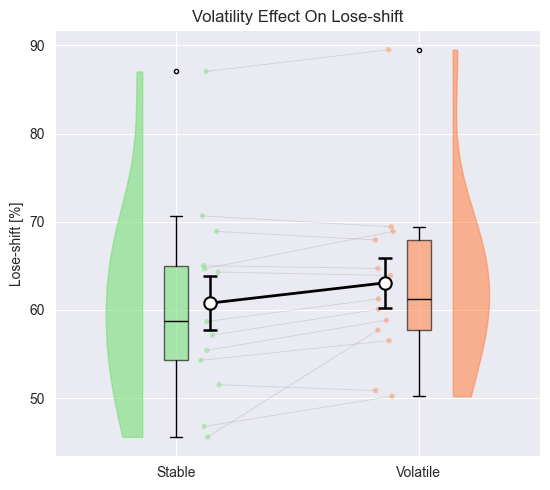

In [15]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_LS
        .pivot_table(
            index=['subject_id'],
            columns='volatility',
            values='lose-shift',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted = combined_results_pivoted.rename_axis(None, axis=1)

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable','volatile'],
        labels=['Stable', 'Volatile'],
        flip=['left','right'],
        output_dir=output_dir,
        ylabel_name='Lose-shift [%]',
        plot_name='volatility effect on lose-shift',
        colours=['#77DF77', '#FF884D']
    );

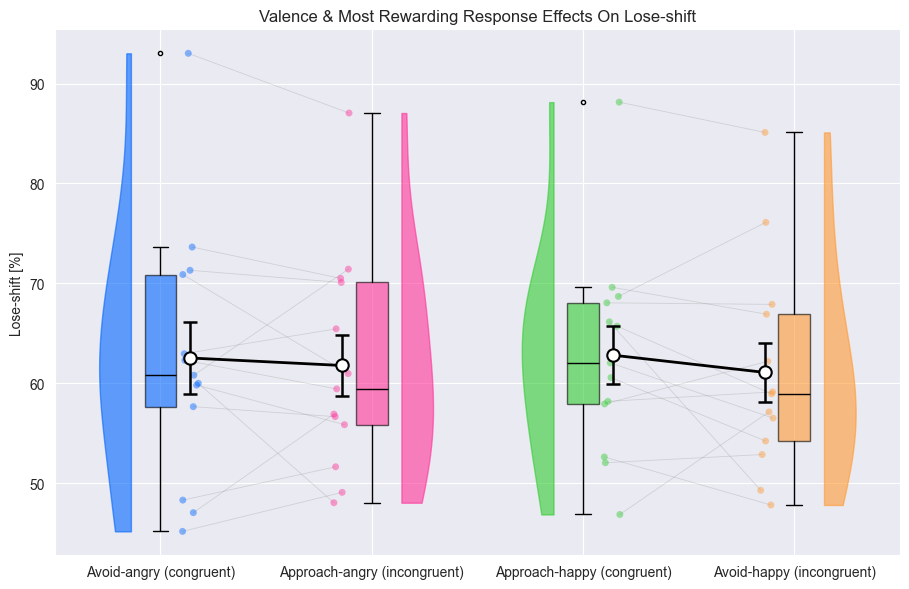

In [16]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_LS
        .pivot_table(
            index=['subject_id'],
            columns=['most_rewarding_response', 'valence'],
            values='lose-shift',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['avoid_angry','approach_angry','approach_happy','avoid_happy'],
        labels=['avoid-angry (congruent)','approach-angry (incongruent)','approach-happy (congruent)','avoid-happy (incongruent)'],
        flip=['left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3)],
        output_dir=output_dir,
        ylabel_name='lose-shift [%]',
        plot_name='valence & most rewarding response effects on lose-shift'
    );

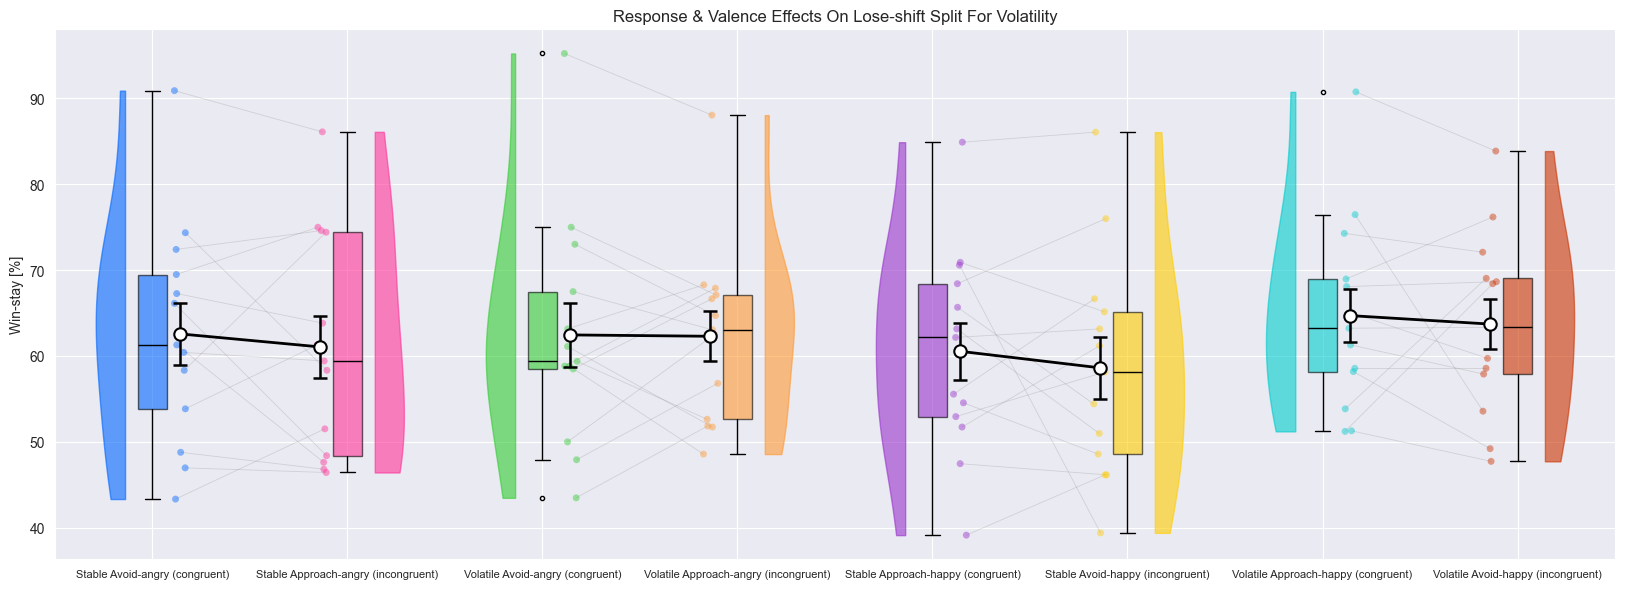

In [17]:
if dataset!='africa':
    # Single-pass aggregation & reshape
    combined_results_pivoted = (
        combined_results_dataframe_LS
        .pivot_table(
            index=['subject_id'],
            columns=['volatility', 'most_rewarding_response', 'valence'],
            values='lose-shift',
            aggfunc='mean'
        )
        .reset_index()
    )
    combined_results_pivoted.columns = [
        '_'.join(str(x) for x in col if x)
        for col in combined_results_pivoted.columns
    ]

    # Plot the two groups using a raincloud plot
    utils.plotting_functions.paired_raincloud(
        combined_results_pivoted,
        columns=['stable_avoid_angry','stable_approach_angry','volatile_avoid_angry','volatile_approach_angry',
                 'stable_approach_happy','stable_avoid_happy','volatile_approach_happy','volatile_avoid_happy'],
        labels=['stable avoid-angry (congruent)','stable approach-angry (incongruent)','volatile avoid-angry (congruent)','volatile approach-angry (incongruent)',
                'stable approach-happy (congruent)','stable avoid-happy (incongruent)', 'volatile approach-happy (congruent)','volatile avoid-happy (incongruent)'],
        flip=['left','right','left','right','left','right','left','right'],
        connect_pairs=[(0, 1), (2, 3), (4, 5), (6, 7)],
        output_dir=output_dir,
        ylabel_name='win-stay [%]',
        plot_name='response & valence effects on lose-shift split for volatility'
    );